# Predict Student Performance

## Objective
Predict a student's **final grade** using **multiple linear regression** and analyze which factors affect performance most.

This project uses a diverse row-level dataset with 500 students. Students have different study hours, attendance, previous scores, assignment scores, sleep hours, and final grades.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("data/student_performance.csv")
print("Dataset shape:", df.shape)
display(df.head(10))

Dataset shape: (500, 6)


,study_hours,attendance_percent,previous_score,assignment_score,sleep_hours,final_grade
0,3.7,100.0,71.0,65.4,6.5,52.5
1,6.1,86.5,77.5,86.8,6.5,65.3
2,1.1,64.8,71.2,62.4,7.0,42.5
3,8.7,64.4,75.4,96.5,7.1,71.4
4,7.0,66.6,47.4,80.1,6.8,58.6
5,4.8,83.9,71.7,69.4,8.4,74.8
6,4.8,93.2,63.4,94.4,5.1,62.4
7,6.2,55.0,63.7,74.5,6.4,60.6
8,4.9,85.3,84.5,67.3,7.8,69.4
9,5.0,89.1,57.7,77.5,6.7,70.6


## 1. Explore the dataset

In [14]:
print("Missing values:")
display(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe().round(2))

Missing values:


study_hours           0
attendance_percent    0
previous_score        0
assignment_score      0
sleep_hours           0
final_grade           0
dtype: int64


Summary statistics:


,study_hours,attendance_percent,previous_score,assignment_score,sleep_hours,final_grade
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,5.59,77.96,63.46,78.41,6.97,64.06
std,2.35,11.81,14.23,13.45,1.19,9.52
min,0.50,43.30,25.00,38.20,4.00,39.00
25%,3.90,70.35,53.48,69.05,6.20,57.50
50%,5.60,78.05,63.75,78.35,6.90,63.50
75%,7.20,86.50,73.43,87.93,7.80,70.72
max,12.00,100.00,98.00,100.00,10.00,96.40


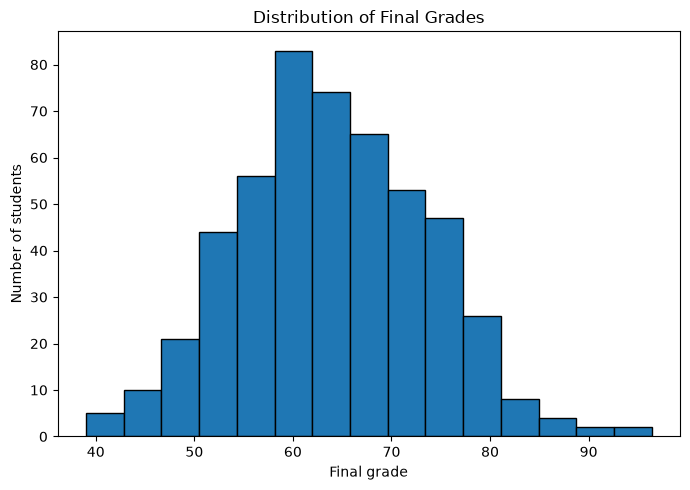

In [15]:
plt.figure(figsize=(7,5))
plt.hist(df["final_grade"], bins=15, edgecolor="black")
plt.xlabel("Final grade")
plt.ylabel("Number of students")
plt.title("Distribution of Final Grades")
plt.tight_layout()
plt.savefig("outputs/final_grade_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

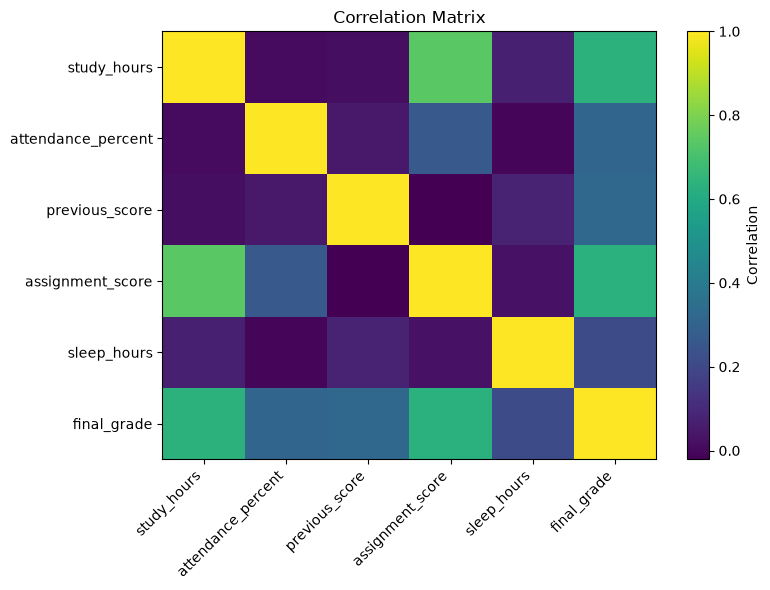

In [16]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("outputs/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Prepare features and target

Target: `final_grade`

Predictors:
- study hours
- attendance
- previous score
- assignment score
- sleep hours

In [17]:
X = df.drop(columns="final_grade")
y = df["final_grade"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 400
Testing records: 100


## 3. Train Multiple Linear Regression

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": np.round(predictions, 2)
})
display(results.head(10))

,Actual,Predicted
0,62.0,57.26
1,58.6,61.37
2,57.5,67.51
3,55.8,54.13
4,70.1,70.35
5,77.0,67.99
6,59.9,70.83
7,74.4,67.74
8,65.3,65.39
9,68.6,60.42


## 4. Evaluate the model

- **MAE:** average absolute prediction error.
- **RMSE:** penalizes larger errors more.
- **R²:** proportion of final-grade variation explained by the model.

In [19]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")

MAE  : 4.84
RMSE : 5.86
R²   : 0.672


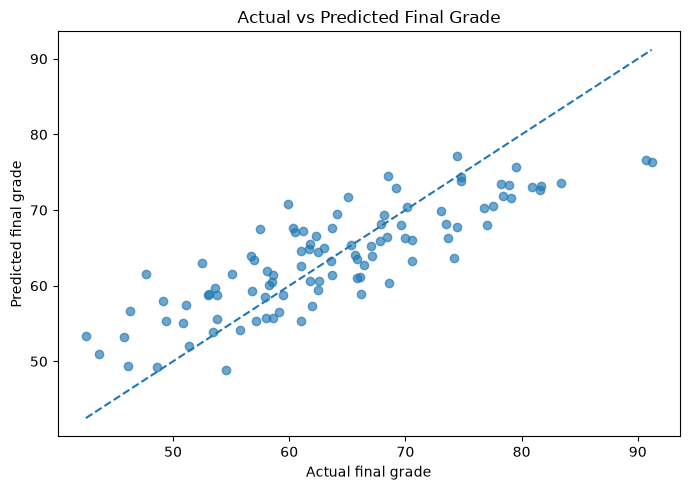

In [20]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, predictions, alpha=0.65)
lims = [min(y_test.min(), predictions.min()), max(y_test.max(), predictions.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual final grade")
plt.ylabel("Predicted final grade")
plt.title("Actual vs Predicted Final Grade")
plt.tight_layout()
plt.savefig("outputs/actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Analyze the regression coefficients

A coefficient shows the expected change in final grade for a one-unit increase in that feature, holding the other features constant.

In [21]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

display(coefficients)

,Feature,Coefficient
0,study_hours,1.536529
4,sleep_hours,1.157145
3,assignment_score,0.198861
2,previous_score,0.194540
1,attendance_percent,0.160654


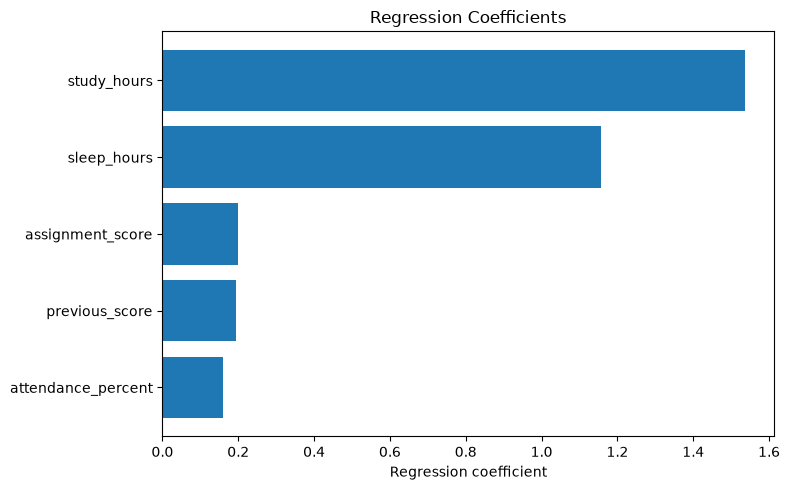

In [22]:
plot_data = coefficients.sort_values("Coefficient")
plt.figure(figsize=(8,5))
plt.barh(plot_data["Feature"], plot_data["Coefficient"])
plt.xlabel("Regression coefficient")
plt.title("Regression Coefficients")
plt.tight_layout()
plt.savefig("outputs/regression_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Compare relative importance

The predictors use different units. Standardized coefficients put them on a common scale, making their relative influence easier to compare.

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

standardized_model = LinearRegression()
standardized_model.fit(X_scaled, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Standardized_Coefficient": standardized_model.coef_
})
importance["Absolute_Importance"] = importance["Standardized_Coefficient"].abs()
importance = importance.sort_values("Absolute_Importance", ascending=False)

display(importance)

,Feature,Standardized_Coefficient,Absolute_Importance
0,study_hours,4.066161,4.066161
2,previous_score,2.814408,2.814408
3,assignment_score,2.461552,2.461552
1,attendance_percent,2.159130,2.159130
4,sleep_hours,1.457167,1.457167


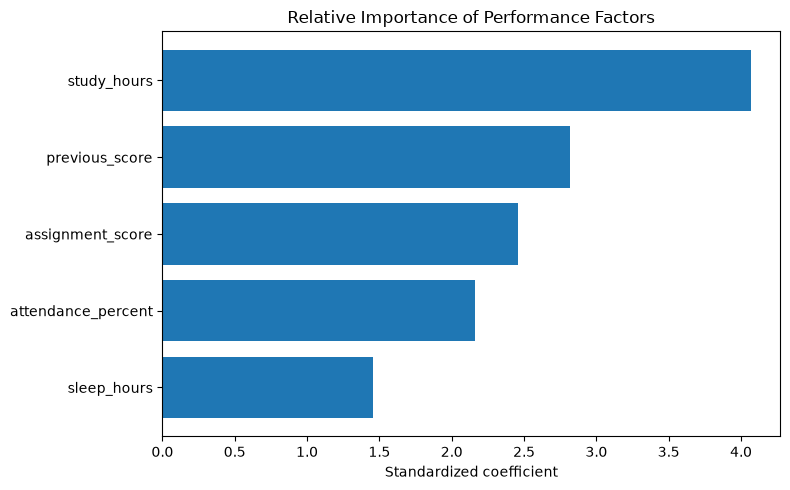

In [24]:
plot_data = importance.sort_values("Standardized_Coefficient")
plt.figure(figsize=(8,5))
plt.barh(plot_data["Feature"], plot_data["Standardized_Coefficient"])
plt.xlabel("Standardized coefficient")
plt.title("Relative Importance of Performance Factors")
plt.tight_layout()
plt.savefig("outputs/standardized_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Conclusion

Multiple linear regression predicts final grade from several student-performance factors at once.

The **standardized coefficients** provide the clearest comparison of which factors are most strongly associated with final grade. A larger absolute coefficient indicates a stronger relationship in this model.

This is an association-based analysis; it does not prove that one factor directly causes a change in student performance.